In [1]:
import sys
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras as keras
sys.modules["tensorflow.keras"] = keras
sys.modules["keras"] = keras

import tensorflow as tf
import qkeras
from qkeras import QDense, QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu
from tf_keras.models import Sequential
from tf_keras.layers import MaxPooling2D, Activation, Flatten, Dropout, BatchNormalization

2026-04-29 00:00:32.660386: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777413632.791625    1296 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777413632.828262    1296 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-29 00:00:33.160478: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import scipy.io
import numpy as np

def load_svhn(path):
    data = scipy.io.loadmat(path)
    X = data["X"]
    y = data["y"].reshape(-1)

    X = np.transpose(X, (3,0,1,2))

    y[y == 10] = 0

    return X, y

In [3]:
import gc

X_train, y_train = load_svhn("/home/slopin/DAT255-project/SVHN/Data/train_32x32.mat")
X_test, y_test   = load_svhn("/home/slopin/DAT255-project/SVHN/Data/test_32x32.mat")

#Adding the extra data, but only a subset of it to avoid memory issues.
X_ex_tmp, y_ex_tmp = load_svhn("/home/slopin/DAT255-project/SVHN/Data/extra_32x32.mat")
indices = np.random.choice(len(X_ex_tmp), 100000, replace=False)
X_extra_sampled = X_ex_tmp[indices]
y_extra_sampled = y_ex_tmp[indices]

#Garbage collecting to free up memory.
del X_ex_tmp, y_ex_tmp
gc.collect()

#Concatenating the extra data with the training data.
X_train = np.concatenate((X_train, X_extra_sampled), axis=0)
y_train = np.concatenate((y_train, y_extra_sampled), axis=0)

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

input_shape = (32, 32, 3)

In [14]:
data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(height_factor=0.02, width_factor=0.02),
    keras.layers.RandomZoom(0.05),
    keras.layers.RandomContrast(0.02),
])

inputs = keras.Input(shape=input_shape)

x = data_augmentation(inputs)

x = QConv2D(                                  #starting with a higher bit width of 8 for the first convolutional layer to preserve accuracy, and using 6 bots for the subsequent convolutional layers to save memory, as the later layers are less sensitive to quantization errors than the first layer.
    filters=32,
    kernel_size=(3, 3),
    name='qconv0',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
)(x)
x = BatchNormalization()(x)
x = QActivation(activation=quantized_relu(4), name='relu0')(x) #Adding 2 integer bits to the activation quantizer to allow for some headroom in the activations due to BatchNormalization.
x = MaxPooling2D(name="pool0")(x)

x= QConv2D(
    filters=64,
    kernel_size=(3, 3),
    name='qconv1',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
)(x)
x = BatchNormalization()(x)
x = QActivation(activation=quantized_relu(4), name='relu1')(x)
x = MaxPooling2D(name="pool1")(x)

x= QConv2D(
    filters=128,
    kernel_size=(3, 3),
    name='qconv2',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
)(x)
x = BatchNormalization()(x)
x = QActivation(activation=quantized_relu(4), name='relu2')(x)
x = MaxPooling2D(name="pool2")(x)

x = Flatten()(x)

x = QDense(                                          #reducing bit width to 4 for the hidden layer to save memory, as the hidden layer is less sensitive to quantization errors than the output layer.
    512,
    name='qdense0',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
)(x)
x = QActivation(activation=quantized_relu(4), name='relu3')(x)

x = Dropout(0.2)(x)

x = QDense(                                          #increasing bit width to 8 for the final layer to improve accuracy, as the output layer is more sensitive to quantization errors.
    10,
    name='qdense1',
    kernel_quantizer=quantized_bits(4, 0, alpha=1),
    bias_quantizer=quantized_bits(4, 0, alpha=1),
)(x)

outputs = keras.layers.Activation(activation='softmax', name='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

/home/slopin/DAT255-project/.venv_qkeras2/lib/python3.10/site-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [15]:
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity

#Calculate endstep based on the dataset size and batch size
batch_size = 256
epochs = 60
num_samples = len(X_train) * 0.75 
steps_per_epoch = np.ceil(num_samples / batch_size).astype(np.int32)
end_step = steps_per_epoch * epochs

pruning_params = {
    'pruning_schedule': sparsity.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.75, # Target 75% sparsity
        begin_step=0,
        end_step=end_step
    )
}
def prune_layers(layer):
    # We only want to prune layers with weights
    if isinstance(layer, (QConv2D, QDense)):
        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
    return layer
#using clone_model with a custom clone_function to apply pruning selectively, as prune_low_magnitude cant interpret the data augmentation layers that were added to the model definition.
model_prune = tf.keras.models.clone_model(model, clone_function=prune_layers)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=4, min_lr=1e-7, verbose=1),

    sparsity.UpdatePruningStep(), 
    sparsity.PruningSummaries(log_dir='model_pruned/logs')
]

model_prune.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 sequential_1 (Sequential)   (None, 32, 32, 3)         0         
                                                                 
 prune_low_magnitude_qconv0  (None, 30, 30, 32)        1762      
  (PruneLowMagnitude)                                            
                                                                 
 batch_normalization_3 (Bat  (None, 30, 30, 32)        128       
 chNormalization)                                                
                                                                 
 relu0 (QActivation)         (None, 30, 30, 32)        0         
                                                                 
 pool0 (MaxPooling2D)        (None, 15, 15, 32)        0   

In [16]:
opt = keras.optimizers.Adam(learning_rate=1e-3, amsgrad=True)
model_prune.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

In [17]:
model_prune.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    shuffle=True
)

model_prune = sparsity.strip_pruning(model_prune) # Strip the wrappers to get the plain Keras model back

2026-04-29 00:21:47.159013: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2128982016 exceeds 10% of free system memory.
2026-04-29 00:21:59.150340: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2128982016 exceeds 10% of free system memory.


Epoch 1/60


E0000 00:00:1777414924.111726    1296 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape ingradient_tape/model_1/relu2/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


677/677 [==============================] - 31s 40ms/step - loss: 0.8815 - accuracy: 0.7148 - val_loss: 0.6896 - val_accuracy: 0.7847 - lr: 0.0010
Epoch 2/60
677/677 [==============================] - 24s 36ms/step - loss: 0.3809 - accuracy: 0.8859 - val_loss: 0.4720 - val_accuracy: 0.8547 - lr: 0.0010
Epoch 3/60
677/677 [==============================] - 25s 36ms/step - loss: 0.3047 - accuracy: 0.9081 - val_loss: 0.4554 - val_accuracy: 0.8587 - lr: 0.0010
Epoch 4/60
677/677 [==============================] - 25s 37ms/step - loss: 0.2620 - accuracy: 0.9223 - val_loss: 0.3517 - val_accuracy: 0.8949 - lr: 0.0010
Epoch 5/60
677/677 [==============================] - 24s 36ms/step - loss: 0.2338 - accuracy: 0.9305 - val_loss: 0.3590 - val_accuracy: 0.8911 - lr: 0.0010
Epoch 6/60
677/677 [==============================] - 25s 37ms/step - loss: 0.2139 - accuracy: 0.9365 - val_loss: 0.3369 - val_accuracy: 0.8977 - lr: 0.0010
Epoch 7/60
677/677 [==============================] - 24s 36ms/step -

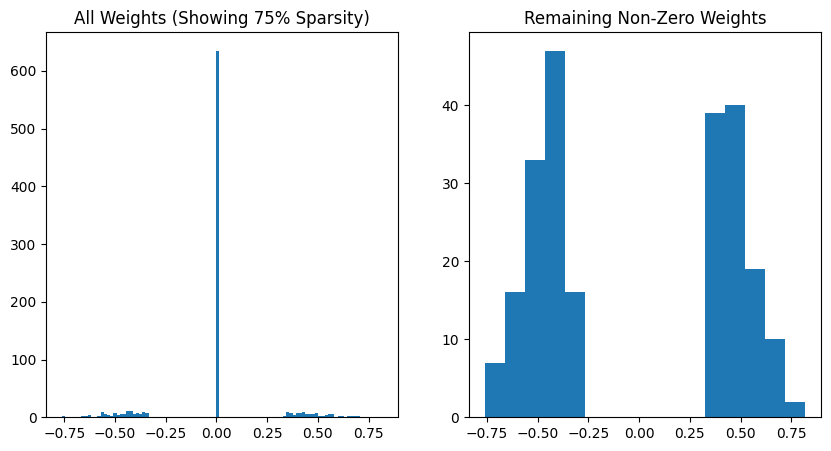

In [18]:
import matplotlib.pyplot as plt

target_layer = model_prune.get_layer('qconv0')

# Pruned layers wrap the original; we need to access the weights via get_weights()
# [0] is usually the kernel (weights), [1] is the bias (if exists)
weights = target_layer.get_weights()[0]

w = weights.flatten()
h, b = np.histogram(w, bins=100)
non_zero_w = w[w != 0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(w, bins=100)
plt.title("All Weights (Showing 75% Sparsity)")

plt.subplot(1, 2, 2)
plt.hist(non_zero_w, bins=16) # 16 bins for 4-bit
plt.title("Remaining Non-Zero Weights")
plt.show()

Global Model Sparsity: 73.50%


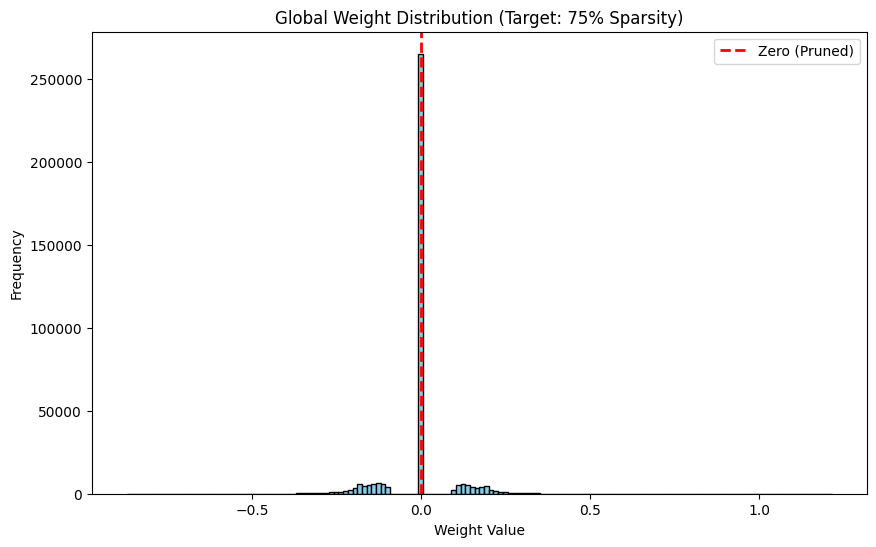

In [19]:
all_weights = []

# Loop through every layer in your pruned model
for layer in model_prune.layers:
    # Get all weight arrays for this layer (kernel, bias, etc.)
    layer_weights = layer.get_weights()
    
    if len(layer_weights) > 0:
        # The first element [0] is usually the kernel (the weights we prune)
        # We flatten it to 1D and add it to our list
        all_weights.append(layer_weights[0].flatten())

# Combine all layers into one giant array
total_w = np.concatenate(all_weights)

# Calculate the actual sparsity (how many are EXACTLY zero)
actual_sparsity = np.mean(total_w == 0)
print(f"Global Model Sparsity: {actual_sparsity * 100:.2f}%")

# Plotting the "Sparsity Spike"
plt.figure(figsize=(10, 6))
plt.hist(total_w, bins=150, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero (Pruned)')
plt.title(f"Global Weight Distribution (Target: 75% Sparsity)")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [20]:
model_prune.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

score = model_prune.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.21069632470607758
Test accuracy: 0.9404578804969788


In [21]:
model_prune.save('Model_Qkeras_UniformPrecision_pruned.h5')